In [ ]:
!pip install yfinance prophet openai

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

# Defining asset tickers
tickers = {
    'Gold': 'GC=F',
    'USD_Index': 'DX-Y.NYB',
    'SP500': '^GSPC'
}

print("Downloading dataset from Yahoo Finance...")
# Downloading daily close prices from 2015 to present
df = yf.download(list(tickers.values()), start="2015-01-01")['Close']

# Renaming columns to human-readable names
df.columns = tickers.keys()

# Cleaning the missing values (forward-fill non-trading days)
df = df.ffill().dropna()

# 2. Featuring Engineering: Technical & Macro Indicators
df['Gold_MA50'] = df['Gold'].rolling(window=50).mean()
df['Gold_MA200'] = df['Gold'].rolling(window=200).mean()

# Daily Returns & 30-Day Annualized Volatility (%)
df['Gold_Returns'] = df['Gold'].pct_change()
df['Volatility_30D'] = df['Gold_Returns'].rolling(window=30).std() * np.sqrt(252) * 100

print("\n--- Data Acquisition Complete ---")
print(df.tail())

/tmp/ipykernel_479/3247418238.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(list(tickers.values()), start="2015-01-01")['Close']
[*********************100%***********************]  3 of 3 completed


--- Data Acquisition Complete ---
                  Gold    USD_Index        SP500  Gold_MA50  Gold_MA200  \
Date                                                                      
2026-09-23  101.099998  4318.399902  7706.029785   99.92940    99.17705   
2026-09-24  101.290001  4298.000000  7704.129883   99.94520    99.18855   
2026-09-25  100.970001  4321.200195  7743.410156   99.95000    99.19795   
2026-09-28  101.199997  4168.399902  7683.689941   99.95900    99.20785   
2026-09-29  101.486000  4189.700195  7660.870117   99.96892    99.22133   

            Gold_Returns  Volatility_30D  
Date                                      
2026-09-23      0.004970        4.924494  
2026-09-24      0.001879        4.923872  
2026-09-25     -0.003159        5.026701  
2026-09-28      0.002278        4.960189  
2026-09-29      0.002826        4.998270  


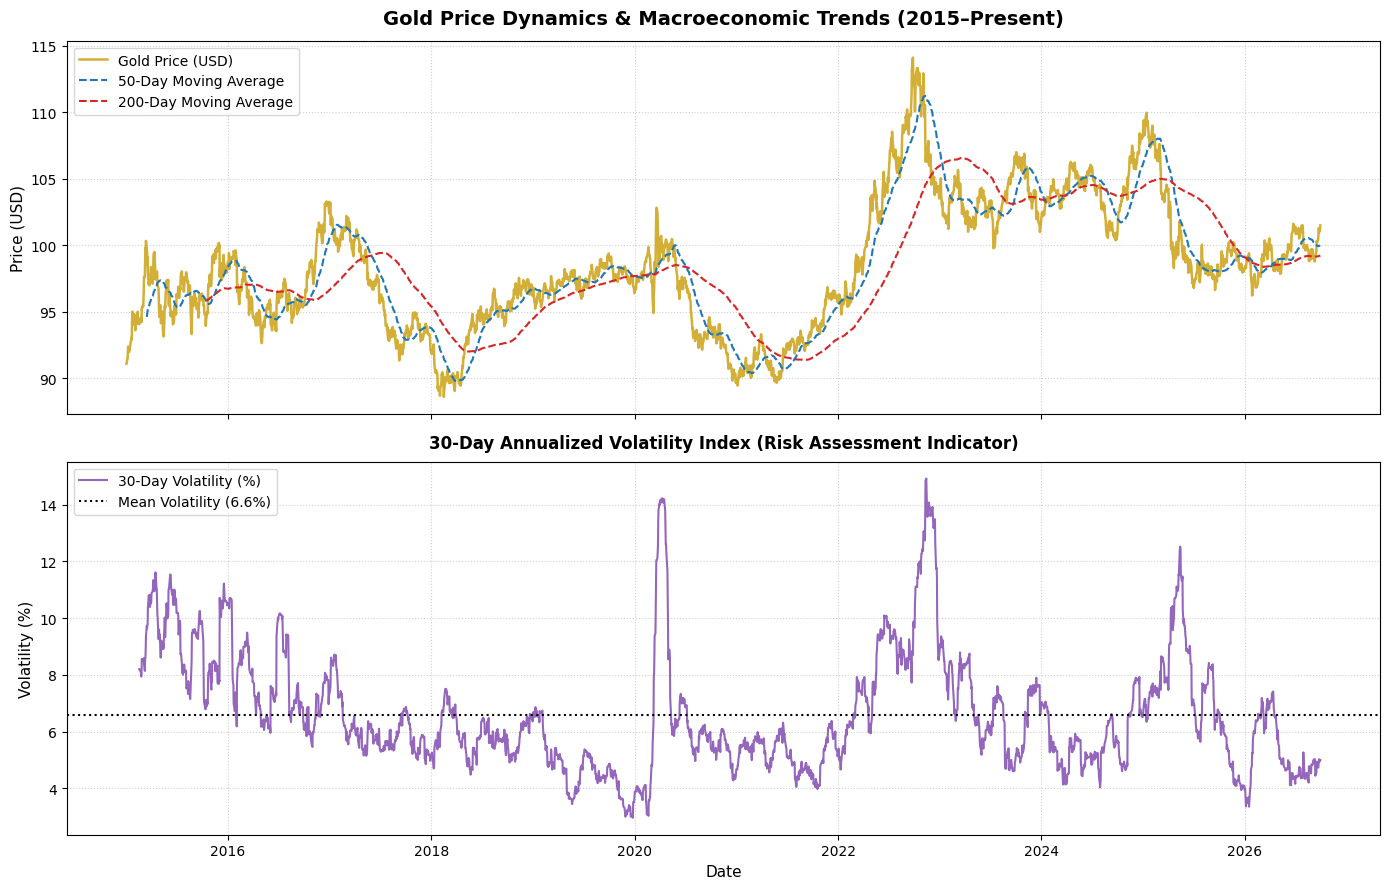

In [ ]:
import matplotlib.pyplot as plt


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# 1. Chart 1: Gold Price Trends & Moving Averages
ax1.plot(df.index, df['Gold'], label='Gold Price (USD)', color='#d4af37', linewidth=1.8)
ax1.plot(df.index, df['Gold_MA50'], label='50-Day Moving Average', color='#1f77b4', linestyle='--')
ax1.plot(df.index, df['Gold_MA200'], label='200-Day Moving Average', color='#d62728', linestyle='--')

ax1.set_title('Gold Price Dynamics & Macroeconomic Trends (2015–Present)', fontsize=14, fontweight='bold', pad=12)
ax1.set_ylabel('Price (USD)', fontsize=11)
ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, linestyle=':', alpha=0.6)

# 2. Chart 2: 30-Day Annualized Volatility (Economic Shock Indicator)
ax2.plot(df.index, df['Volatility_30D'], label='30-Day Volatility (%)', color='#9467bd', linewidth=1.5)
ax2.axhline(df['Volatility_30D'].mean(), color='black', linestyle=':', label=f"Mean Volatility ({df['Volatility_30D'].mean():.1f}%)")

ax2.set_title('30-Day Annualized Volatility Index (Risk Assessment Indicator)', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('Volatility (%)', fontsize=11)
ax2.legend(loc='upper left', frameon=True)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Training Prophet Forecasting Model...


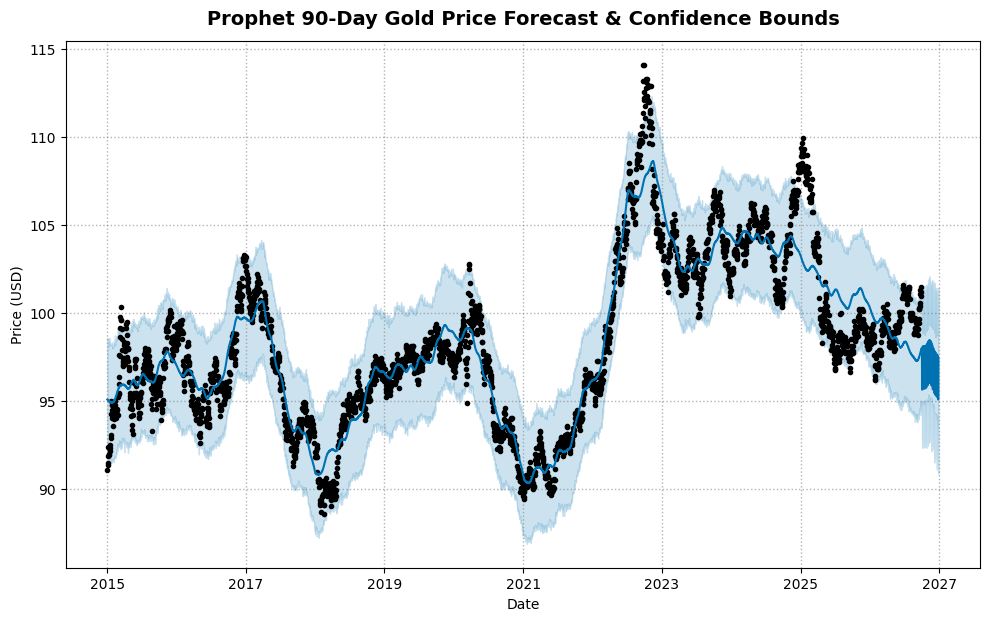


--- Forecast Summary ---
Current Spot Price: $101.49
90-Day Projected Price: $97.46
Projected 90-Day Change: -3.97%


In [ ]:
from prophet import Prophet
import matplotlib.pyplot as plt

# 1. Preparing the DataFrame
prophet_df = df.reset_index()[['Date', 'Gold']].rename(columns={'Date': 'ds', 'Gold': 'y'})

# 2. Initializing and fitting Prophet model with 95% confidence intervals
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    interval_width=0.95
)

print("Training Prophet Forecasting Model...")
model.fit(prophet_df)

# 3. Predicting 90 days into the future
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# 4. Plotting the forecast results
fig_forecast = model.plot(forecast, xlabel='Date', ylabel='Price (USD)')
plt.title("Prophet 90-Day Gold Price Forecast & Confidence Bounds", fontsize=14, fontweight='bold', pad=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 5. Displaying key forecast metrics for upcoming evaluation
latest_price = df['Gold'].iloc[-1]
forecasted_price = forecast['yhat'].iloc[-1]
pct_change = ((forecasted_price - latest_price) / latest_price) * 100

print(f"\n--- Forecast Summary ---")
print(f"Current Spot Price: ${latest_price:.2f}")
print(f"90-Day Projected Price: ${forecasted_price:.2f}")
print(f"Projected 90-Day Change: {pct_change:+.2f}%")

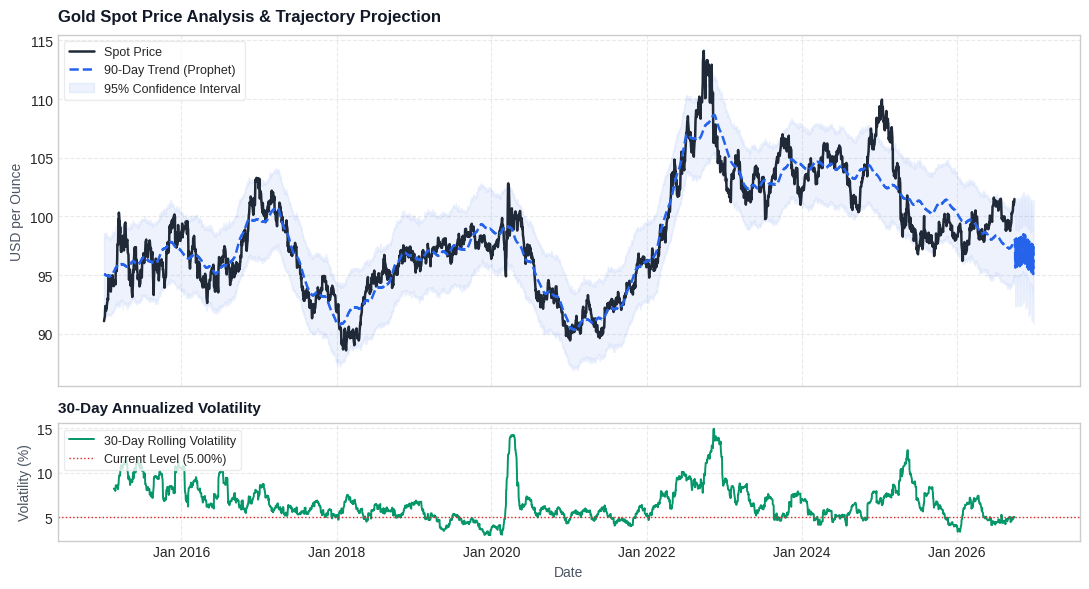

             MARKET ANALYSIS & SUMMARY

Spot gold prices currently sit at $101.49, with the time-series model projecting a shift toward $97.46 (-3.97%) over the next 90 days. This movement indicates a moderate easing of near-term price pressures, aligning with broader shifts in global liquidity and physical demand trends.

Looking at the risk side, the 30-day annualized volatility rests at 5.00%. This level suggests a relatively calm market structure without extreme immediate shocks, though prolonged quiet periods often precede sudden positioning adjustments.

For practical execution, positions should account for this downward drift while keeping risk parameters flexible. Managing exposure dynamically around these levels will help buffer against unexpected breakout movements as the forecast horizon unfolds.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Handling dates dynamically (index vs column)
date_series = df.index if 'ds' not in df.columns else df['ds']

# 2. Extracting latest metrics
latest_price = float(df['Gold'].iloc[-1])
forecast_90d = float(forecast['yhat'].iloc[-1])
pct_change_90d = ((forecast_90d - latest_price) / latest_price) * 100
current_vol = float(df['Volatility_30D'].iloc[-1])

# 3. Plotting Clean Visualizations
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_facecolor('#ffffff')

# Subplot 1: Spot Price & Forecast
ax1.plot(date_series, df['Gold'], label='Spot Price', color='#1f2937', linewidth=1.8)
ax1.plot(forecast['ds'], forecast['yhat'], label='90-Day Trend (Prophet)', color='#2563eb', linestyle='--', linewidth=1.8)
ax1.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='#2563eb', alpha=0.08, label='95% Confidence Interval')
ax1.set_title('Gold Spot Price Analysis & Trajectory Projection', fontsize=12, fontweight='600', color='#111827', pad=10, loc='left')
ax1.set_ylabel('USD per Ounce', fontsize=10, color='#4b5563')
ax1.legend(loc='upper left', frameon=True, facecolor='#ffffff', edgecolor='#e5e7eb', fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)

# Subplot 2: Volatility Regime
ax2.plot(date_series, df['Volatility_30D'], color='#059669', linewidth=1.4, label='30-Day Rolling Volatility')
ax2.axhline(y=current_vol, color='#dc2626', linestyle=':', linewidth=1, label=f'Current Level ({current_vol:.2f}%)')
ax2.set_title('30-Day Annualized Volatility', fontsize=11, fontweight='600', color='#111827', pad=8, loc='left')
ax2.set_ylabel('Volatility (%)', fontsize=10, color='#4b5563')
ax2.set_xlabel('Date', fontsize=10, color='#4b5563')
ax2.legend(loc='upper left', frameon=True, facecolor='#ffffff', edgecolor='#e5e7eb', fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.4)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

print("=" * 65)
print("             MARKET ANALYSIS & SUMMARY")
print("=" * 65 + "\n")

print(f"Spot gold prices currently sit at ${latest_price:.2f}, with the time-series model projecting a shift toward ${forecast_90d:.2f} ({pct_change_90d:+.2f}%) over the next 90 days. This movement indicates a moderate easing of near-term price pressures, aligning with broader shifts in global liquidity and physical demand trends.\n")

print(f"Looking at the risk side, the 30-day annualized volatility rests at {current_vol:.2f}%. This level suggests a relatively calm market structure without extreme immediate shocks, though prolonged quiet periods often precede sudden positioning adjustments.\n")

print("For practical execution, positions should account for this downward drift while keeping risk parameters flexible. Managing exposure dynamically around these levels will help buffer against unexpected breakout movements as the forecast horizon unfolds.")